<a href="https://colab.research.google.com/github/Aman2125/DataScience_CampusX_Practice/blob/main/11)aman_vectorized_string_ops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Pivot Table

The pivot table takes simple column-wise data as input, and groups the entries into a two-dimensional table that provides a multidimensional summarization of the data.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
df = sns.load_dataset('tips') # tips is toy dataset inbuilt in seaborn
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# que on the basis of gender find avg total bill
df.groupby('sex')[['total_bill']].mean()

/tmp/ipykernel_240/2814355715.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [4]:
# add on to above find on basis of smoker
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

/tmp/ipykernel_240/2255970741.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [5]:
# for the above we can use pivot to get the result
df.pivot_table(index='sex',columns='smoker',values='total_bill')
# by default here aggregate function is mean

/tmp/ipykernel_240/1725558037.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [6]:
# afffunc
df.pivot_table(index='sex',columns='smoker',values='total_bill' , aggfunc='sum')

/tmp/ipykernel_240/613908510.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill' , aggfunc='sum')


smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [7]:
# all cols together
df.pivot_table(index='sex',columns='smoker', values=['total_bill', 'tip', 'size'])

/tmp/ipykernel_240/3082618174.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker', values=['total_bill', 'tip', 'size'])


size                 tip           total_bill           
smoker       Yes        No       Yes        No        Yes         No
sex                                                                 
Male    2.500000  2.711340  3.051167  3.113402  22.284500  19.791237
Female  2.242424  2.592593  2.931515  2.773519  17.977879  18.105185

In [8]:
# multidimensional
df.pivot_table(index=['sex' , 'smoker'] , columns=['day' , 'time'] , values=['total_bill', 'size', 'tip'] , aggfunc={'size' : 'mean' , 'tip' : 'max' , 'total_bill' : 'sum'})

/tmp/ipykernel_240/1756207755.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex' , 'smoker'] , columns=['day' , 'time'] , values=['total_bill', 'size', 'tip'] , aggfunc={'size' : 'mean' , 'tip' : 'max' , 'total_bill' : 'sum'})


size                                               tip  \
day                Thur              Fri              Sat       Sun  Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner Lunch   
sex    smoker                                                               
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  5.00   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  6.70   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  5.00   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  5.17   

                                                total_bill                \
day                    Fri           Sat    Sun       Thur           Fri   
time          Dinner Lunch Dinner Dinner Dinner      Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       NaN  2.20   4.73  10.00    6.5     191.71   0.00  34.16   
       No        NaN   NaN   3.50   9.00    6.0     369.73   0.00   0.00   
Female Yes       NaN  3.48   4.30   6.50    4.0     134.53   0.00  39.78   
       No        3.0  3.00   3.25   4.67    5.2     381.58  18.78  15.98   

                                                   
day                     Sat           Sun          
time           Dinner Lunch  Dinner Lunch  Dinner  
sex    smoker                                      
Male   Yes     129.46   0.0  589.62   0.0  392.12  
       No       34.95   0.0  637.73   0.0  877.34  
Female Yes      48.80   0.0  304.00   0.0   66.16  
       No       22.75   0.0  247.05   0.0  291.54

In [9]:
# margins
df.pivot_table(index='sex',columns='smoker',values='total_bill' , aggfunc='sum' , margins=True)

/tmp/ipykernel_240/2406198632.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill' , aggfunc='sum' , margins=True)


smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [26]:
# plotting graphs
df = pd.read_csv('/content/expense_data.csv')
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [27]:
df['Category'].value_counts()

,count
Category,
Food,156
Other,60
Transportation,31
Apparel,7
Household,6
Allowance,6
Social Life,5
Education,1
Salary,1


In [28]:
df['date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    object        
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
 11  date            277 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(5), object(6)
memory usage: 26.1+ KB


In [29]:
df['month'] = df['date'].dt.month_name()

In [30]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,date,month
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,2022-03-02 10:11:00,March
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,2022-03-02 10:11:00,March
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,2022-03-01 19:50:00,March
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,2022-03-01 18:56:00,March
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,2022-03-01 18:22:00,March


<Axes: xlabel='month'>

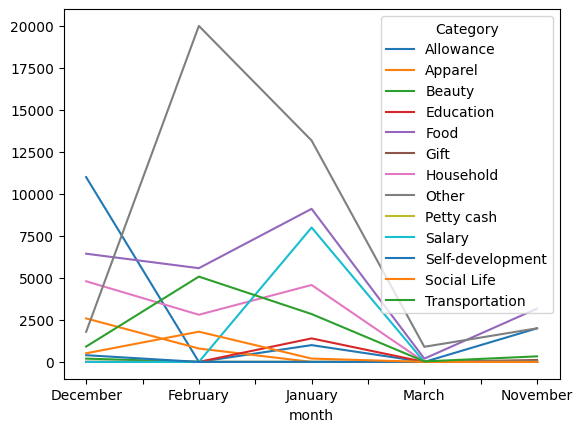

In [31]:
df.pivot_table(index = 'month' , columns='Category' , values='INR' , aggfunc='sum' , fill_value=0).plot()

<Axes: xlabel='month'>

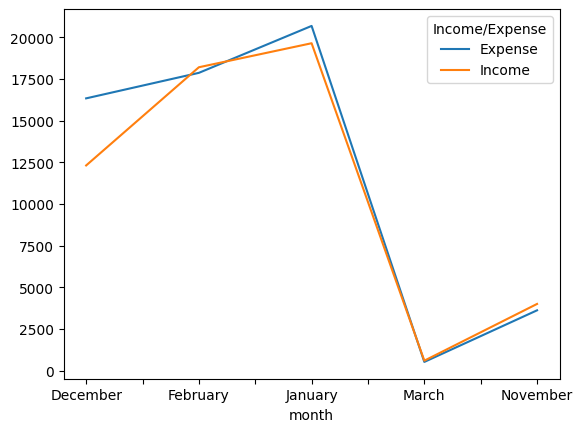

In [32]:
df.pivot_table(index = 'month' , columns='Income/Expense' , values='INR' , aggfunc='sum' , fill_value=0).plot()

#Pandas Strings

In [33]:
import pandas as pd
import numpy as np

In [34]:
# what are vectorized operations
a = np.array([1,2,3,4])
a * 4

array([ 4,  8, 12, 16])

In [35]:
# problem in vectorized operations in vanilla python
s = ['cat','mat',None,'rat']

[i.startswith('c') for i in s]
# here the code will through error because it can not handle missing or null data
# thats why introduced vectorized string ops to solve these and these are fast for larger dataset

AttributeError: 'NoneType' object has no attribute 'startswith'

In [36]:
# how panda solves this issue?
s = pd.Series(['cat','mat',None,'rat'])

#string accessor
s.str.startswith('c')
# fast and optimized for larger dataset

,0
0,True
1,False
2,None
3,False


In [37]:
# import titanic
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
# common functions
# lower/upper/capitalize/title
df['Name'].str.lower().head()
df['Name'].str.capitalize().head()

,Name
0,"Braund, mr. owen harris"
1,"Cumings, mrs. john bradley (florence briggs th..."
2,"Heikkinen, miss. laina"
3,"Futrelle, mrs. jacques heath (lily may peel)"
4,"Allen, mr. william henry"


In [39]:
(# len function
df['Name'][df['Name'].str.len()== 82 ]
# to get the name of the passenger having longest name

,Name
307,"Penasco y Castellana, Mrs. Victor de Satode (M..."


In [40]:
# strip , all spaces removed
df['Name'].str.strip().head()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


In [41]:
# split -> get
# split name into first , second , last name col
df['Name'].str.split(',').str.get(0).head() # for extracting the surname

,Name
0,Braund
1,Cumings
2,Heikkinen
3,Futrelle
4,Allen


In [46]:
# filtering
# startswith/endswith
df[df['Name'].str.startswith('A')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.0500,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.00,1,5,347082,31.2750,NaN,S
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.00,1,5,347077,31.3875,NaN,S
40,41,0,3,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",female,40.00,1,0,7546,9.4750,NaN,S
49,50,0,3,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.00,1,0,349237,17.8000,NaN,S
68,69,1,3,"Andersson, Miss. Erna Alexandra",female,17.00,4,2,3101281,7.9250,NaN,S
91,92,0,3,"Andreasson, Mr. Paul Edvin",male,20.00,0,0,347466,7.8542,NaN,S
114,115,0,3,"Attalah, Miss. Malake",female,17.00,0,0,2627,14.4583,NaN,C
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.00,4,2,347082,31.2750,NaN,S
144,145,0,2,"Andrew, Mr. Edgardo Samuel",male,18.00,0,0,231945,11.5000,NaN,S


In [47]:
# isdigit/isalpha
df[df['Name'].str.isdigit()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [49]:
from pandas.core.arrays.categorical import contains
#applying regex
# contains
# search john -> both case
df[df['Name'].str.contains('john' , case=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
41,42,0,2,"Turpin, Mrs. William John Robert (Dorothy Ann ...",female,27.0,1,0,11668,21.0000,NaN,S
45,46,0,3,"Rogers, Mr. William John",male,NaN,0,0,S.C./A.4. 23567,8.0500,NaN,S
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S
112,113,0,3,"Barton, Mr. David John",male,22.0,0,0,324669,8.0500,NaN,S
117,118,0,2,"Turpin, Mr. William John Robert",male,29.0,1,0,11668,21.0000,NaN,S
160,161,0,3,"Cribb, Mr. John Hatfield",male,44.0,0,1,371362,16.1000,NaN,S
162,163,0,3,"Bengtsson, Mr. John Viktor",male,26.0,0,0,347068,7.7750,NaN,S
165,166,1,3,"Goldsmith, Master. Frank John William ""Frankie""",male,9.0,0,2,363291,20.5250,NaN,S


In [54]:
# slicing
df['Name'].str[::4] # same like python

,Name
0,BnMO r
1,Cn .hreFe gTe
2,Hkni n
3,"Fe,saee lae"
4,Anriae
...,...
886,"Mv,vus"
887,GaM.red
888,"Js,sCeel""r"
889,"B,.rol"


# Date and Time

### Timestamp Object

Time stamps reference particular moments in time (e.g., Oct 24th, 2022 at 7:00pm)

### Creating Timestamp objects

In [57]:
# creating a timestamp
type(pd.Timestamp('2026/3/5')) # year , month , day

pandas._libs.tslibs.timestamps.Timestamp

In [58]:
# variations
pd.Timestamp('2023-1-5')
pd.Timestamp('2023, 1, 5')

Timestamp('2023-01-05 00:00:00')

In [59]:
from pandas._libs.tslibs.timestamps import Timestamp
# only year
pd.Timestamp('2026')

Timestamp('2026-01-01 00:00:00')

In [60]:
from pandas._libs.tslibs.timestamps import Timestamp
# using text
pd.Timestamp('5th March 2026')

Timestamp('2026-03-05 00:00:00')

In [62]:
# providing time also
pd.Timestamp('5th March 2026 2:59 PM')

Timestamp('2026-03-05 14:59:00')

In [64]:
# using datetime.datetime object , from python
import datetime as dt
x = pd.Timestamp(dt.datetime(2026 , 3 ,5,15,12)) # datetime object different than timestamp
x

Timestamp('2026-03-05 15:12:00')

In [67]:
# fetching attributes
x.year
x.month
x.second

0

In [68]:
# why separate objects to handle data and time when python already has datetime functionality?

- syntax wise datetime is very convenient
- But the performance takes a hit while working with huge data. List vs Numpy Array
- The weaknesses of Python's datetime format inspired the NumPy team to add a set of native time series data type to NumPy.
- The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly.

In [69]:
import numpy as np
date = np.array('2015-07-04', dtype=np.datetime64)
date

array('2015-07-04', dtype='datetime64[D]')

In [70]:
date + np.arange(12)

array(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
       '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
       '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
      dtype='datetime64[D]')

- Because of the uniform type in NumPy datetime64 arrays, this type of operation can be accomplished much more quickly than if we were working directly with Python's datetime objects, especially as arrays get large

- Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64

- From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in a Series or DataFrame

### DatetimeIndex Object

A collection of pandas timestamp

In [72]:
# from strings
type(pd.DatetimeIndex(['2026/1/1','2025/1/1','2024/1/1']))

pandas.core.indexes.datetimes.DatetimeIndex

In [74]:
# using python datetime object
pd.DatetimeIndex([dt.datetime(2026,1,1) , dt.datetime(2025,1,1)])

DatetimeIndex(['2026-01-01', '2025-01-01'], dtype='datetime64[ns]', freq=None)

In [77]:
from pandas.core.indexes.datetimes import DatetimeIndex
# using pd.timestamps
dt_index = pd.DatetimeIndex([pd.Timestamp(2026,1,1) , pd.Timestamp(2025,1,1)])
dt_index

DatetimeIndex(['2026-01-01', '2025-01-01'], dtype='datetime64[ns]', freq=None)

In [79]:
# using datetimeindex as index
pd.Series([1,2] , index = dt_index)

,0
2026-01-01,1
2025-01-01,2


### date_range function



In [85]:
# generate daily dates in a given range
pd.date_range(start='2023/1/5',end='2023/1/28',freq='D')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
               '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-28'],
              dtype='datetime64[ns]', freq='D')

In [81]:
# alternate days in a given range
pd.date_range(start='2023/1/5',end='2023/2/28',freq='3D')  # 3d means date after 3days

DatetimeIndex(['2023-01-05', '2023-01-08', '2023-01-11', '2023-01-14',
               '2023-01-17', '2023-01-20', '2023-01-23', '2023-01-26',
               '2023-01-29', '2023-02-01', '2023-02-04', '2023-02-07',
               '2023-02-10', '2023-02-13', '2023-02-16', '2023-02-19',
               '2023-02-22', '2023-02-25', '2023-02-28'],
              dtype='datetime64[ns]', freq='3D')

In [82]:
# B -> business days
pd.date_range(start='2023/1/5',end='2023/2/28',freq='B')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-09', '2023-01-10',
               '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-23', '2023-01-24', '2023-01-25', '2023-01-26',
               '2023-01-27', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-06', '2023-02-07',
               '2023-02-08', '2023-02-09', '2023-02-10', '2023-02-13',
               '2023-02-14', '2023-02-15', '2023-02-16', '2023-02-17',
               '2023-02-20', '2023-02-21', '2023-02-22', '2023-02-23',
               '2023-02-24', '2023-02-27', '2023-02-28'],
              dtype='datetime64[ns]', freq='B')

In [89]:
# W -> one week per day
pd.date_range(start='2026/2/5',end='2026/2/28',freq='W')

DatetimeIndex(['2026-02-08', '2026-02-15', '2026-02-22'], dtype='datetime64[ns]', freq='W-SUN')

In [90]:
pd.date_range(start='2026/2/5',end='2026/2/28',freq='W-THU')

DatetimeIndex(['2026-02-05', '2026-02-12', '2026-02-19', '2026-02-26'], dtype='datetime64[ns]', freq='W-THU')

In [92]:
# H -> Hourly data(factor)
pd.date_range(start='2026/2/5',end='2026/2/8',freq='5H')

/tmp/ipykernel_240/140778444.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2026/2/5',end='2026/2/8',freq='5H')


DatetimeIndex(['2026-02-05 00:00:00', '2026-02-05 05:00:00',
               '2026-02-05 10:00:00', '2026-02-05 15:00:00',
               '2026-02-05 20:00:00', '2026-02-06 01:00:00',
               '2026-02-06 06:00:00', '2026-02-06 11:00:00',
               '2026-02-06 16:00:00', '2026-02-06 21:00:00',
               '2026-02-07 02:00:00', '2026-02-07 07:00:00',
               '2026-02-07 12:00:00', '2026-02-07 17:00:00',
               '2026-02-07 22:00:00'],
              dtype='datetime64[ns]', freq='5h')

In [94]:
# ME -> month end
pd.date_range(start='2026/2/5',end='2026/2/28',freq='ME')

DatetimeIndex(['2026-02-28'], dtype='datetime64[ns]', freq='ME')

In [96]:
# MS -> month start
pd.date_range(start='2026/2/1',end='2026/2/28',freq='MS')

DatetimeIndex(['2026-02-01'], dtype='datetime64[ns]', freq='MS')

In [98]:
# YE -> year end
pd.date_range(start='2026/2/5',end='2030/2/28',freq='YE')

DatetimeIndex(['2026-12-31', '2027-12-31', '2028-12-31', '2029-12-31'], dtype='datetime64[ns]', freq='YE-DEC')

In [100]:
# using periods (number of results)
pd.date_range(start='2026/2/5',periods= 25 ,freq='3D')

DatetimeIndex(['2026-02-05', '2026-02-08', '2026-02-11', '2026-02-14',
               '2026-02-17', '2026-02-20', '2026-02-23', '2026-02-26',
               '2026-03-01', '2026-03-04', '2026-03-07', '2026-03-10',
               '2026-03-13', '2026-03-16', '2026-03-19', '2026-03-22',
               '2026-03-25', '2026-03-28', '2026-03-31', '2026-04-03',
               '2026-04-06', '2026-04-09', '2026-04-12', '2026-04-15',
               '2026-04-18'],
              dtype='datetime64[ns]', freq='3D')

### to_datetime function

converts an existing objects to pandas timestamp/datetimeindex object

In [101]:
# simple series example

s = pd.Series(['2023/1/1','2022/1/1','2021/1/1'])
pd.to_datetime(s).dt.day_name() # dt accesor used to acces the things like str

,0
0,Sunday
1,Saturday
2,Friday


In [102]:
# with errors
s = pd.Series(['2023/1/1','2022/1/1','2021/130/1']) # error as month is 130
pd.to_datetime(s,errors='coerce').dt.month_name() # used errors = coerce , now code will run without error

,0
0,January
1,January
2,NaN


In [103]:
df = pd.read_csv('/content/expense_data.csv')
df.shape

(277, 11)

In [104]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [105]:
df['Date'] = pd.to_datetime(df['Date'])

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


### dt accessor

Accessor object for datetimelike properties of the Series values.

In [107]:
df['Date'].dt.is_quarter_start

,Date
0,False
1,False
2,False
3,False
4,False
...,...
272,False
273,False
274,False
275,False


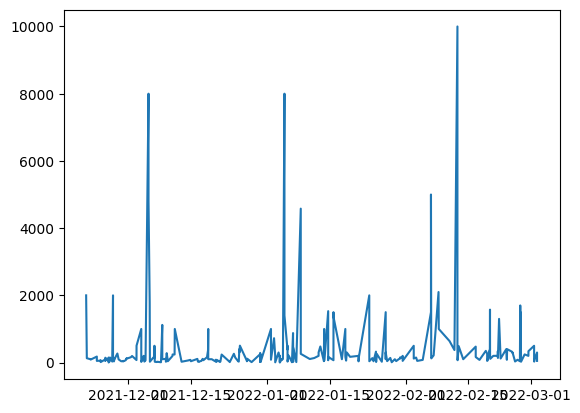

In [108]:
# plot graph
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['INR'])

In [109]:
# day name wise bar chart/month wise bar chart

df['day_name'] = df['Date'].dt.day_name()

In [110]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday


<Axes: ylabel='INR'>

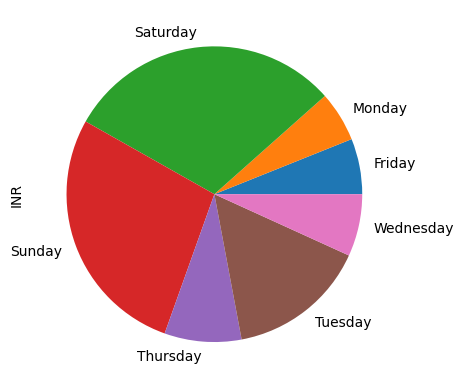

In [112]:
from pandas.core.groupby import groupby
df.groupby('day_name')['INR'].sum().plot(kind = 'pie')